Regression Based ANN model that predict the gold price

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
data=pd.read_csv("gold_price_forecasting_dataset.csv")

In [3]:
data.head()

,date,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
0,2021-06-11,1877.400024,1877.400024,1902.300049,1875.199951,1900.900024,349,1887.828561,1860.180005,1790.618891,-0.008869,0.009353,0.007538,54.722931,19.724030,24.933953,1918.242879,1853.797124
1,2021-06-14,1864.000000,1864.000000,1866.599976,1846.500000,1866.199951,41,1886.799997,1863.403337,1790.972225,-0.007138,0.006411,0.007711,49.391919,16.433420,23.233846,1913.119794,1861.530206
2,2021-06-15,1854.500000,1854.500000,1867.199951,1854.400024,1866.400024,78,1881.757132,1865.506669,1791.701114,-0.005097,0.004572,0.007474,45.972581,12.910196,21.169116,1914.969370,1858.380630
3,2021-06-16,1859.500000,1859.500000,1860.099976,1809.199951,1859.400024,117,1876.428554,1868.296667,1792.241113,0.002696,0.004348,0.007240,48.012515,10.401571,19.015607,1915.862799,1856.657196
4,2021-06-17,1773.800049,1773.800049,1823.300049,1769.599976,1811.800049,1135,1859.514282,1867.953337,1791.595558,-0.046088,0.016895,0.011288,28.293542,1.481124,15.508710,1938.202457,1823.567538


In [4]:
data.tail()

,date,adj close,close,high,low,open,volume,ma_7,ma_30,ma_90,daily_return,volatility_7,volatility_30,rsi,macd,macd_signal,bb_upper,bb_lower
1162,2026-01-26,5079.700195,5079.700195,5095.600098,5052.200195,5081.500000,180,4822.971401,4513.550000,4189.464434,0.020799,0.014470,0.014899,82.883455,169.000739,122.250355,5019.523790,4155.806191
1163,2026-01-27,5079.899902,5079.899902,5079.899902,5079.899902,5079.899902,34,4889.199986,4540.029997,4204.998877,0.000039,0.014091,0.014677,82.887953,182.167754,134.233835,5096.080527,4134.329434
1164,2026-01-28,5301.600098,5301.600098,5301.600098,5301.600098,5301.600098,112054,4991.085728,4573.413330,4223.419990,0.043643,0.014892,0.016210,86.978544,208.093290,149.005726,5210.931481,4117.128480
1165,2026-01-29,5318.399902,5318.399902,5586.200195,5097.500000,5415.700195,23709,5070.914272,4607.136654,4241.718877,0.003169,0.014215,0.016193,87.227702,227.374043,164.679389,5310.168254,4112.721688
1166,2026-01-30,4713.899902,4713.899902,5440.500000,4700.000000,5376.399902,23709,5054.071429,4620.783317,4252.532210,-0.113662,0.051106,0.027369,50.088570,191.666666,170.076845,5302.863243,4158.856679


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1167 entries, 0 to 1166
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1167 non-null   object 
 1   adj close      1167 non-null   float64
 2   close          1167 non-null   float64
 3   high           1167 non-null   float64
 4   low            1167 non-null   float64
 5   open           1167 non-null   float64
 6   volume         1167 non-null   int64  
 7   ma_7           1167 non-null   float64
 8   ma_30          1167 non-null   float64
 9   ma_90          1167 non-null   float64
 10  daily_return   1167 non-null   float64
 11  volatility_7   1167 non-null   float64
 12  volatility_30  1167 non-null   float64
 13  rsi            1167 non-null   float64
 14  macd           1167 non-null   float64
 15  macd_signal    1167 non-null   float64
 16  bb_upper       1167 non-null   float64
 17  bb_lower       1167 non-null   float64
dtypes: float

In [6]:
data.isnull().sum()

date             0
adj close        0
close            0
high             0
low              0
open             0
volume           0
ma_7             0
ma_30            0
ma_90            0
daily_return     0
volatility_7     0
volatility_30    0
rsi              0
macd             0
macd_signal      0
bb_upper         0
bb_lower         0
dtype: int64

In [7]:
data.columns

Index(['date', 'adj close', 'close', 'high', 'low', 'open', 'volume', 'ma_7',
       'ma_30', 'ma_90', 'daily_return', 'volatility_7', 'volatility_30',
       'rsi', 'macd', 'macd_signal', 'bb_upper', 'bb_lower'],
      dtype='object')

Feature Selection :

In [8]:
# x=data.drop('close',axis=1)
# y=data['close']

In [9]:
X = data[['open', 'high', 'low', 'volume']]
y = data['close']   # or next-day close if you use shifting


In [10]:
# x_scaler=MinMaxScaler()
# y_scaler=MinMaxScaler()
# x = x.drop('date', axis=1)
# x_scaled=x_scaler.fit_transform(x)
# y=np.array(y).reshape(-1,1)
# y_scaled=y_scaler.fit_transform(y)
# # y_scaled=scaler.fit_transform(y)

In [13]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1))


In [14]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

In [15]:
model=Sequential()

#Input + Hidden Layer 1
model.add(Dense(128,activation='relu',input_shape=(4,)))
model.add(Dropout(0.3))

#Hidden layer 2
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))

#Hidden layer 3
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.3))

#Output layer
model.add(Dense(1))

C:\Users\91932\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [17]:
early_stop=EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

In [18]:
history=model.fit(x_train,y_train,
                  validation_split=0.2,
                  epochs=100,
                  batch_size=32,
                  callbacks=[early_stop])

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 6153489.0000 - mae: 2362.4922 - val_loss: 6273619.5000 - val_mae: 2396.8562
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6143825.0000 - mae: 2360.7158 - val_loss: 6251862.0000 - val_mae: 2392.8228
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6097162.5000 - mae: 2351.9165 - val_loss: 6155868.5000 - val_mae: 2374.8196
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5922648.0000 - mae: 2318.5967 - val_loss: 5844266.5000 - val_mae: 2315.1619
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5427775.5000 - mae: 2220.1575 - val_loss: 5085330.0000 - val_mae: 2162.4780
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4399677.0000 - mae: 1999.4972 - val_loss: 3683585.0000 - val_mae: 1846.0245
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2786390.7500 - mae: 1590.7266 - val_loss: 1796248.1250 - val_mae: 1298.7802
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - l

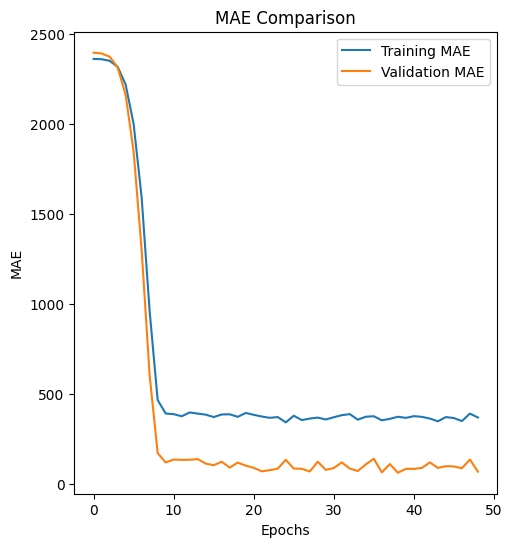

In [19]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history.history['mae'],label='Training MAE')
plt.plot(history.history['val_mae'],label='Validation MAE')
plt.title("MAE Comparison")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()

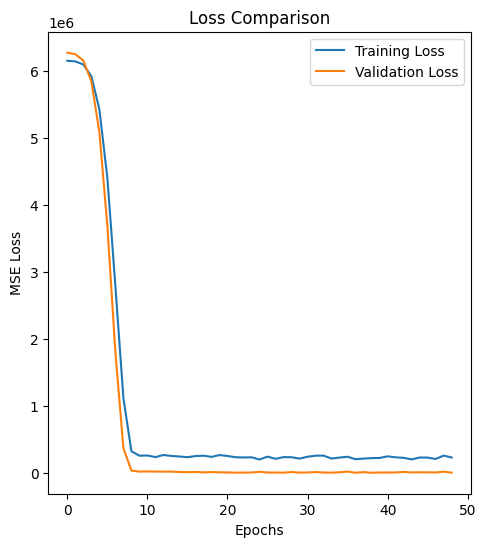

In [20]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

plt.show()


In [21]:
test_loss, test_mae = model.evaluate(x_test, y_test)
print("Test Loss:", test_loss)
print("Test MAE:", test_mae)


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4471.5127 - mae: 62.3940 
Test Loss: 4471.5126953125
Test MAE: 62.39403533935547


In [ ]:
# model.save("Gold_Price_Prediction.keras")

In [ ]:
# import joblib

# joblib.dump(x_scaler, "x_scaler.pkl")
# joblib.dump(y_scaler, "y_scaler.pkl")


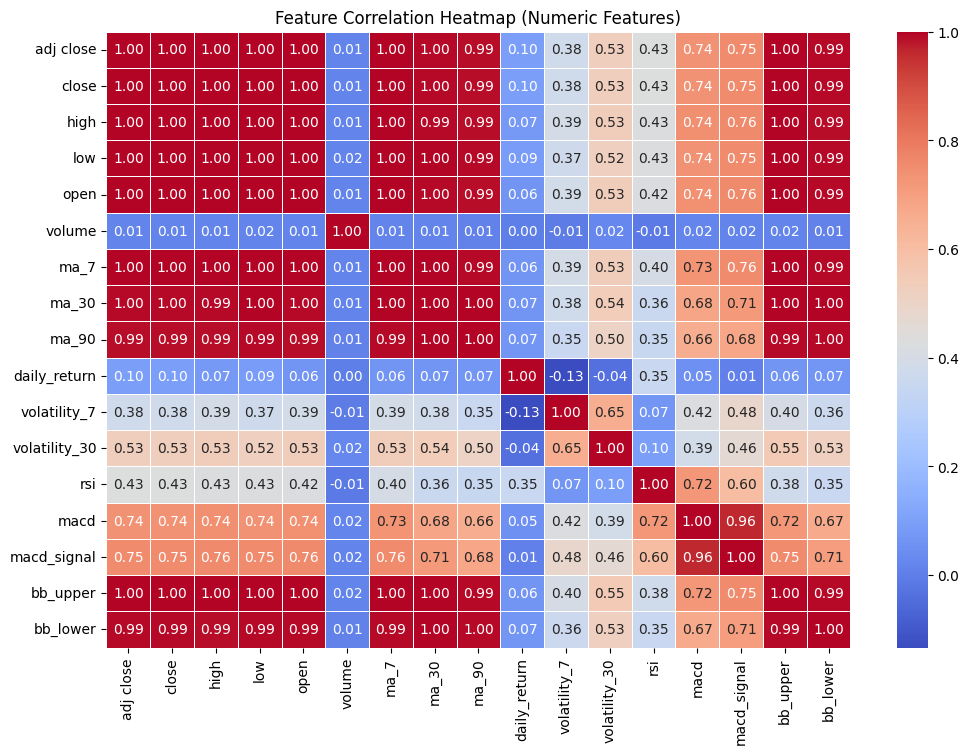

In [23]:
import seaborn as sns
numeric_data = data.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
corr = numeric_data.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap (Numeric Features)")
plt.show()


In [24]:
x = data.drop(['date','close'], axis=1)


In [25]:
print(x.shape)
print(x.columns)


(1167, 16)
Index(['adj close', 'high', 'low', 'open', 'volume', 'ma_7', 'ma_30', 'ma_90',
       'daily_return', 'volatility_7', 'volatility_30', 'rsi', 'macd',
       'macd_signal', 'bb_upper', 'bb_lower'],
      dtype='object')


In [26]:
import joblib

bundle = {
    "model": model,
    "x_scaler": x_scaler,
    "y_scaler": y_scaler
}

joblib.dump(bundle, "gold_price_prediction.pkl")



['gold_price_prediction.pkl']